In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Salary Data.csv")
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [3]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [6]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [7]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [8]:
age=df['Age'].mean()
df['Age']=df['Age'].fillna(age)

experience=df['Years of Experience'].mean()
df['Years of Experience']=df['Years of Experience'].fillna(experience)

salary=df['Salary'].mean()
df['Salary']=df['Salary'].fillna(salary)

In [9]:
df.isnull().sum()

,0
Age,0
Gender,2
Education Level,2
Job Title,2
Years of Experience,0
Salary,0


In [10]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# let take one feature: Years of Experience
# target: Salary

features = ['Years of Experience']

X = df[features]
y = df['Salary']

# create and train model
model = LinearRegression()

model.fit(X, y)

# predict
y_pred = model.predict(X)

# R2 Score
r2 = r2_score(y, y_pred)

print("R2 Score: ", r2)

R2 Score:  0.865528278393677


In [11]:
print("\nEnter Employee Details")

experience = float(input("Enter Years of Experience: "))

user_data = pd.DataFrame({
    'Years of Experience': [experience]
})

prediction = model.predict(user_data)

print("\nPrediction Result")
print("Predicted Salary:", round(prediction[0], 2))


Enter Employee Details
Enter Years of Experience: 6

Prediction Result
Predicted Salary: 72988.28


R2 Score: 0.865528278393677


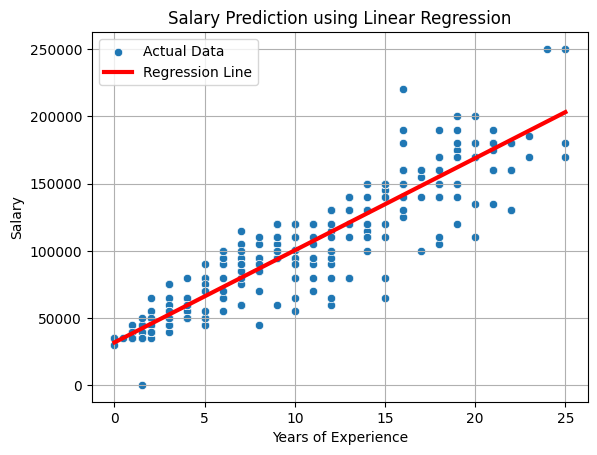

In [12]:
x = df[['Years of Experience']]
y = df['Salary']

m = LinearRegression()

m.fit(x, y)

y_pred = m.predict(x)

r2 = r2_score(y, y_pred)

print("R2 Score:", r2)

x_range = np.linspace(
    x['Years of Experience'].min(),
    x['Years of Experience'].max(),
    100
)

x_new = pd.DataFrame({
    'Years of Experience': x_range
})

y_new = m.predict(x_new)

sns.scatterplot(
    x=x.to_numpy().flatten(),
    y=y,
    label="Actual Data"
)

sns.lineplot(
    x=x_range,
    y=y_new,
    color="red",
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.grid(True)

plt.show()

R2 Score : 0.865528278393677

Enter Employee Details
Enter Years of Experience : 8

Prediction Result
Predicted Salary : 86677.3


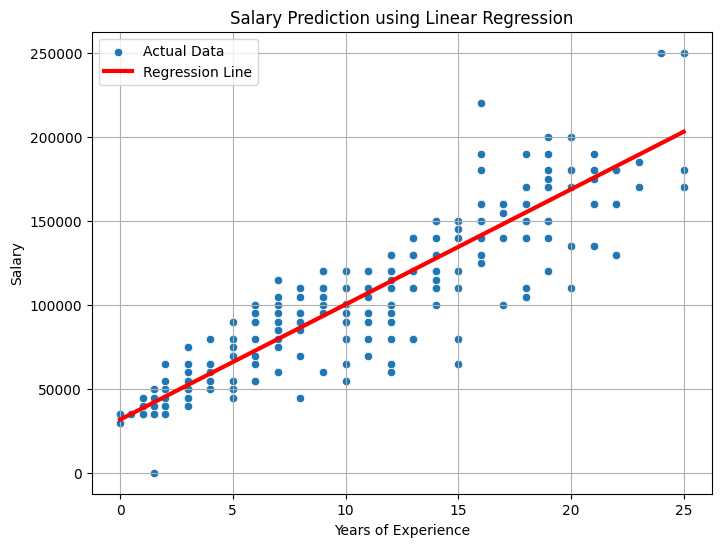

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ---------------------------------------------
# Select Features and Target
# ---------------------------------------------

features = ['Years of Experience']

X = df[features]
y = df['Salary']

# ---------------------------------------------
# Create and Train Model
# ---------------------------------------------

model = LinearRegression()

model.fit(X, y)

# ---------------------------------------------
# Predict
# ---------------------------------------------

y_pred = model.predict(X)

# ---------------------------------------------
# Model Evaluation
# ---------------------------------------------

r2 = r2_score(y, y_pred)

print("R2 Score :", r2)

# ---------------------------------------------
# User Input
# ---------------------------------------------

print("\nEnter Employee Details")

experience = float(input("Enter Years of Experience : "))

user_data = pd.DataFrame({
    'Years of Experience': [experience]
})

prediction = model.predict(user_data)

print("\nPrediction Result")

print("Predicted Salary :", round(prediction[0], 2))

# ---------------------------------------------
# Graph
# ---------------------------------------------

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Years of Experience'],
    y=df['Salary'],
    label="Actual Data"
)

sns.lineplot(
    x=df['Years of Experience'],
    y=y_pred,
    color='red',
    linewidth=3,
    label="Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Linear Regression")
plt.grid(True)

plt.show()